# Time-scale modification using an enhanced phase vocoder

## Libraries and Algorithms

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import get_window, spectrogram
from typing import Tuple, Optional

In [74]:
def set_ola_parameters(sample_rate: int, rate_factor: float) -> Tuple[int, int, int]:
    '''
    Parameters for Overlap-Add (OLA) method
    N: Frame Size (FFT size)
    Ra: Analysis Hop (input window step)
    Rs: Synthesis Hop (output window step)
    rate_factor: Desired duration stretch factor (alpha)
        - formular = Rs / Ra
        - rate_factor > 1.0 for slow down (stretch)
        - rate_factor < 1.0 but > 0.0 for speed up (compress)
    
    To calculate suitable N for a given sample rate where N is a power of 2
        - the frequency bin for music resolution should be <= 20Hz
            as the lowest notes of A0 is approximately 27.5Hz
            and the human ear can hear in range of 20Hz to 20kHz
        - time transient is the inverse of frequency resolution
    
    N = sample_rate / frequency_bin
    '''
    list_N = [256, 512, 1024, 2048, 4096, 8192, 16384]
    pre_N = sample_rate // 20
    N = next((n for n in list_N if n >= pre_N), 16384)
    Ra = N // 4
    Rs = int(rate_factor * Ra)

    return (N, Ra, Rs)

def phase_vocoder(audio_data: np.ndarray, rate_factor: float, sample_rate: int = 44100) -> np.ndarray:
    '''
    Enchanted Phase Vocoder Method for Time-Scale Modification (frequency domain OLA)

    inputs:
        - audio_data: numpy array of audio samples (e.g., from a WAV file)
        - rate_factor: Scaling factor (alpha)
        - sample_rate: Sampling rate of the audio data (default is 44100 Hz)
    
    outputs:
        - y_time_domain: Time-scaled audio data as a 1D numpy array
        - N: Frame size (windowed size)
        - Ra: Analysis hop size
    '''
    if rate_factor <= 0:
        raise ValueError("Rate factor must be greater than zero.")
    
    # --- OLA Initialization ---
    N, Ra, Rs = set_ola_parameters(sample_rate, rate_factor)
    if len(audio_data.shape) == 2: audio_data = audio_data.mean(axis=1)

    x_time_domain = audio_data.astype(np.float64)
    x_len = len(x_time_domain)

    # Preallocate output array
    y_len = int(x_len * rate_factor) + N
    y_time_domain = np.zeros(y_len)
    
    window = get_window('hann', N)
    # window = get_window('blackman', N)
    
    # Accumulated phase for each frequency bin to store phase information across frames
    # Also, only need to store N/2+1 bins for real-valued signals (rfft)
    phase_accumulator = np.zeros(N // 2 + 1)
    
    # Set initial positions ola pointers
    input_pos = 0
    output_pos = 0
    
    # --- Main Processing Loop ---
    while input_pos < x_len - N:
        # Extract the current input frame with size N and apply window
        x_frame = x_time_domain[input_pos : input_pos + N] * window
        
        # Perform real-valued FFT as voice/music signals are real-valued
        X_freqency_domain = np.fft.rfft(x_frame)
        magnitude = np.abs(X_freqency_domain)
        phase = np.angle(X_freqency_domain)
        
        # Phase Propagation (The Core of Phase Vocoder)
        #? Key idea: Adjust the phase to maintain the correct frequency content over time
        #! Helps from: Gemini

        # Expected phase increase if the frequency was constant
        # phi(expected) = (2 * pi * k{frequency bin index} / N) * Ra
        k = np.arange(N // 2 + 1)
        phi_expected = (2 * np.pi * k / N) * Ra
        
        # Calculate the phase change since the last frame (phase difference)
        phase_difference = phase - phase_accumulator
        
        # Unwrap the phase difference to handle jumps from -pi to pi
        # Explanation: The total number of full cycles (laps) that the phase rotation contains
        # For 450 degrees, this is 450/360 = 1.25.
        # The nearest integer number of laps. For 1.25, this is 1. If the phase difference
        # was -1.75, this would be -2. This identifies how many full +-2pi jumps occurred.
        # Then subtraction removes the integer 2pi wraps, isolating the true continuous rotation.
        phase_difference = phase_difference - np.round(phase_difference / (2 * np.pi)) * 2 * np.pi
        
        # Calculate the true instantaneous frequency deviation (dOmega)
        # If the difference is zero, the frequency is perfectly aligned
        # If it is non-zero, the dOmega represents the signal's true movement in frequency during the Ra period
        dOmega = phase_difference - phi_expected
        
        # Scale the frequency deviation to account for the new time scale
        # Stretch: Because the synthesis frames are farther apart, the phase needs to rotate more between them.
        # Scaling dOmega up compensates for the longer time gap, maintaining the original pitch over the new duration.
        # Compress: Because the synthesis frames are closer together, the phase needs to rotate less between them.
        # Scaling dOmega down compensates for the shorter time gap, maintaining the original pitch over the new duration.
        dOmega_scaled = dOmega * rate_factor
        
        # Update the phase accumulator for the next frame
        # New Phase = Previous Phase + Expected Increase + Scaled Deviation
        phase_accumulator = phase_accumulator + phi_expected + dOmega_scaled

        # --- OLA Synthesis ---
        Y_mag = magnitude * np.exp(1j * phase_accumulator)
        
        # Inverse FFT to get the time-domain synthesis frame
        y_frame = np.fft.irfft(Y_mag)
        
        # Apply window again (windowed Overlap-Add)
        windowed_y_frame = y_frame * window
        
        # Overlap-Add (OLA)
        y_time_domain[output_pos : output_pos + N] += windowed_y_frame
        
        # Increment input and output positions
        # Ra determines how much we move forward in the input signal.
        # Rs determines the placement, controlling the speed/duration.
        input_pos += Ra
        output_pos += Rs
        
    # Trim the output signal and
    # Normalize by the window overlap factor of the input
    y = y_time_domain[:output_pos + N] * Ra / N / rate_factor
    
    # Convert to original data type
    y = y.astype(audio_data.dtype) 
    return (y, N, Ra)

def read_input() -> Tuple[str, int, np.ndarray, float, float]:
    filename = input("Enter input WAV filename: ")
    sample_rate, audio_data = wavfile.read('inputs/' + filename + '.wav')

    playback_speed = float(input("Enter playback speed (e.g., 0.5 for half speed, 2.0 for double speed): "))
    rate_factor = 1.0 / playback_speed

    return (filename, sample_rate, audio_data, playback_speed, rate_factor)


## Execution and Spectrogram

In [75]:
import librosa
from scipy.interpolate import interp1d

def calculate_yin_f0_accuracy(x_orig: np.ndarray, x_mod: np.ndarray, Fs: int, Ra: int) -> float:
    '''
    Measures pitch accuracy by calculating the RMSE between the F0 contour 
    of the original signal and the time-aligned F0 contour of the modified signal.

    Generates from Gemini

    inputs:
        x_orig: The original audio signal.
        x_mod: The time-scaled audio signal.
        Fs: The sampling rate (Hz).
        Ra: The analysis hop in samples. Used as the hop length for YIN.

    outputs:
        float: The Root Mean Square Error (RMSE) of the F0 in Hertz (Hz).
    '''
    
    # 1. Calculate F0 Contours using YIN
    x_orig = x_orig.astype(np.float64)
    x_mod = x_mod.astype(np.float64)
    
    # YIN typically uses a hop length (frame advance) similar to the analysis hop (Ra)
    f0_orig, *rest = librosa.pyin(y=x_orig, 
                               fmin=librosa.note_to_hz('C2'), 
                               fmax=librosa.note_to_hz('C7'), 
                               sr=Fs, 
                               frame_length=4 * Ra, 
                               hop_length=Ra)

    f0_mod, *rest = librosa.pyin(y=x_mod, 
                             fmin=librosa.note_to_hz('C2'), 
                             fmax=librosa.note_to_hz('C7'), 
                             sr=Fs, 
                             frame_length=4 * Ra, 
                             hop_length=Ra)

    # Convert unvoiced frames (NaN) to 0 Hz for comparison
    f0_orig = np.nan_to_num(f0_orig, nan=0.0)
    f0_mod = np.nan_to_num(f0_mod, nan=0.0)

    # 2. Time Alignment of F0 Contours (Crucial Step)
    
    M_orig = len(f0_orig)
    M_mod = len(f0_mod)

    if M_mod < 2:
        return np.nan 

    # Define the time axis (frame indices) for the modified F0 contour
    mod_frame_indices = np.arange(M_mod)
    
    # Define the target frame indices for the interpolation (align M_mod to M_orig)
    orig_frame_indices = np.linspace(0, M_mod - 1, M_orig)
    
    # Interpolate the modified F0 contour
    interp_func = interp1d(mod_frame_indices, f0_mod, kind='linear', fill_value='extrapolate')
    f0_mod_aligned = interp_func(orig_frame_indices)
        
    # Ensure both contours have the same length after alignment
    f0_orig = f0_orig[:M_orig]
    f0_mod_aligned = f0_mod_aligned[:M_orig]

    # 3. Calculate F0 RMSE
    
    squared_error = (f0_orig - f0_mod_aligned)**2
    rmse = np.sqrt(np.mean(squared_error))
    
    return rmse


In [76]:
def plot_audio_analysis(filename: str, N: int, Ra: int, sample_rate: Optional[int] = 44100, title: Optional[str] = "Audio") -> None:
    '''
    Plots the time-domain waveform and the frequency-domain spectrogram of an audio signal.
    Generates from Gemini
    '''
    try:
        sample_rate, audio_data = wavfile.read(filename)
    except Exception as e:
        print(f"Error reading {filename}: {e}")
        return
    if len(audio_data.shape) == 2: audio_data = audio_data.mean(axis=1)

    # Normalize data for plotting and spectrogram calculation
    audio_data = audio_data.astype(np.float64) / np.max(np.abs(audio_data))
    
    time_vector = np.linspace(0, len(audio_data) / sample_rate, len(audio_data), endpoint=False)

    plt.figure(figsize=(14, 12))

    # Time Domain (Waveform)
    plt.subplot(2, 1, 1)
    plt.plot(time_vector, audio_data, color='b', linewidth=0.5)
    plt.title(f'{title} - Time Domain Waveform')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.5)
    
    # Spectrogram
    # NPERSEG is analogous to the FFT size (N) in the Phase Vocoder
    # NOVERLAP is analogous to the overlap (N - Ra)
    f, t, Sxx = spectrogram(audio_data, 
                            fs=sample_rate, 
                            window='hann', 
                            nperseg=N,
                            noverlap=N-Ra,
                            scaling='spectrum')
    
    # Convert power spectrogram to dB for better visualization contrast
    Sxx_dB = 10 * np.log10(Sxx + 1e-10)

    plt.subplot(2, 1, 2)
    plt.pcolormesh(t, f, Sxx_dB, shading='gouraud', cmap='viridis')
    plt.ylim([0, sample_rate / 2]) # Limit Y-axis to Nyquist frequency
    plt.colorbar(label='Power/Frequency (dB)')
    plt.title('Spectrogram (Frequency Analysis)')
    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    
    plt.tight_layout() # Adjusts spacing between subplots
    plt.show()

Input file: LJ001-0001
Sample Rate: 22050
Audio Length: 9.66 seconds
Output written to: outputs/LJ001-0001_1.5x.wav
Audio Length: 6.46 seconds
F0 RMSE: 113.099


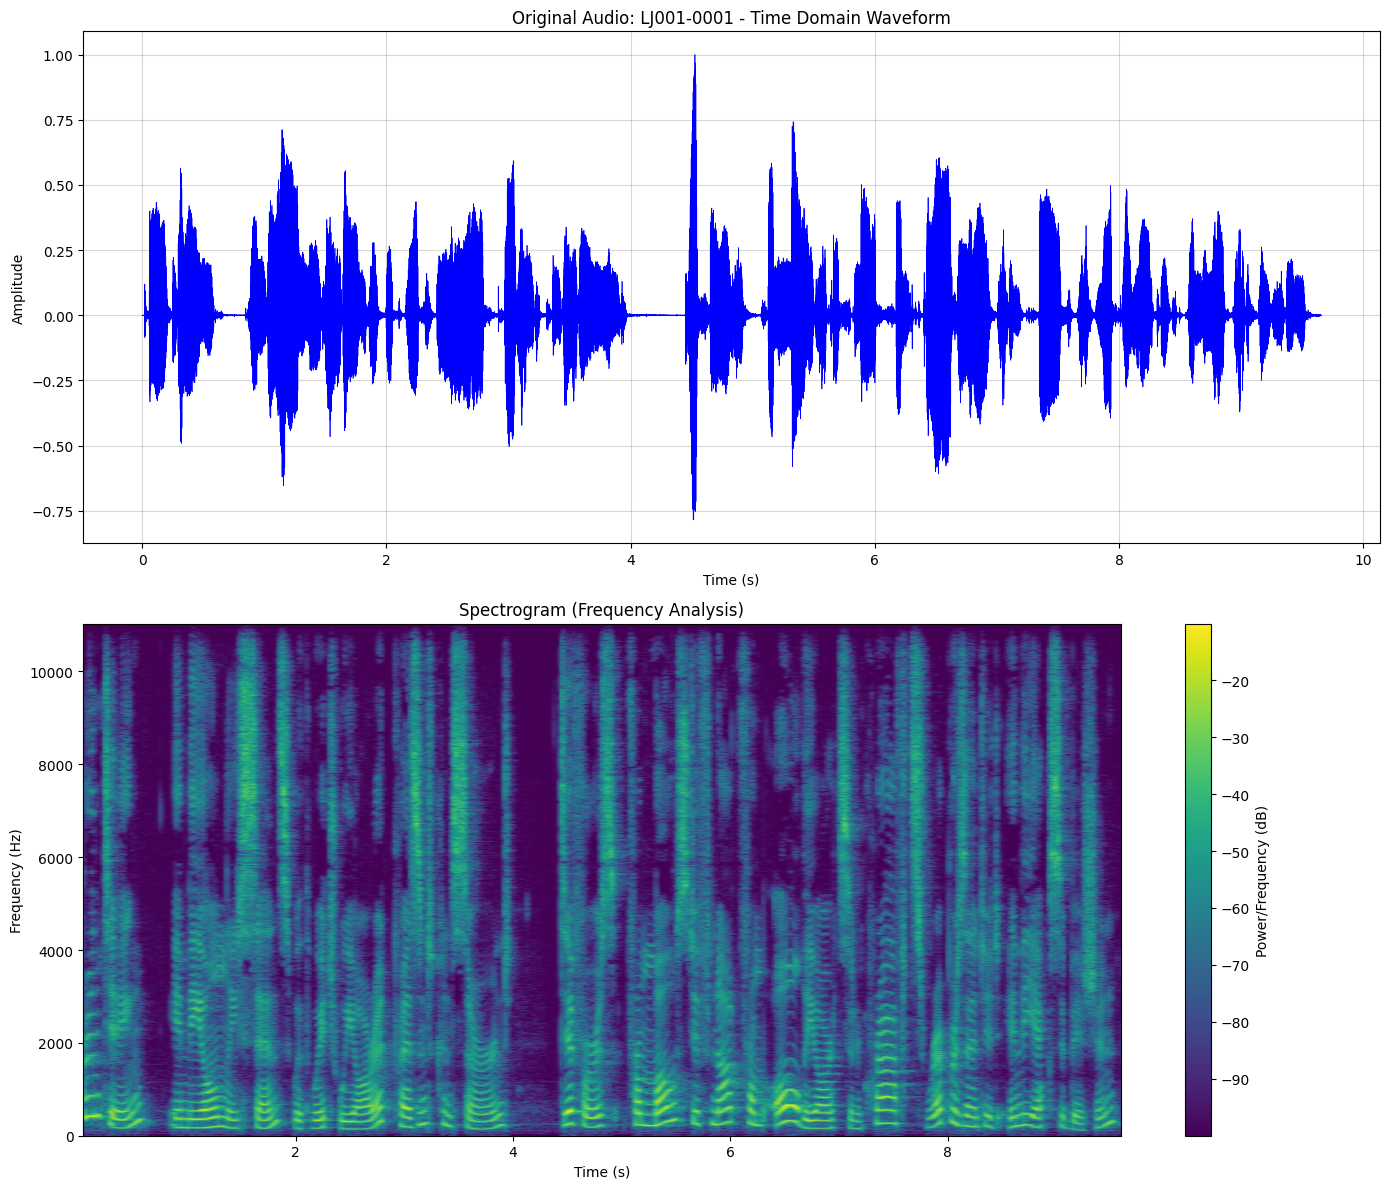

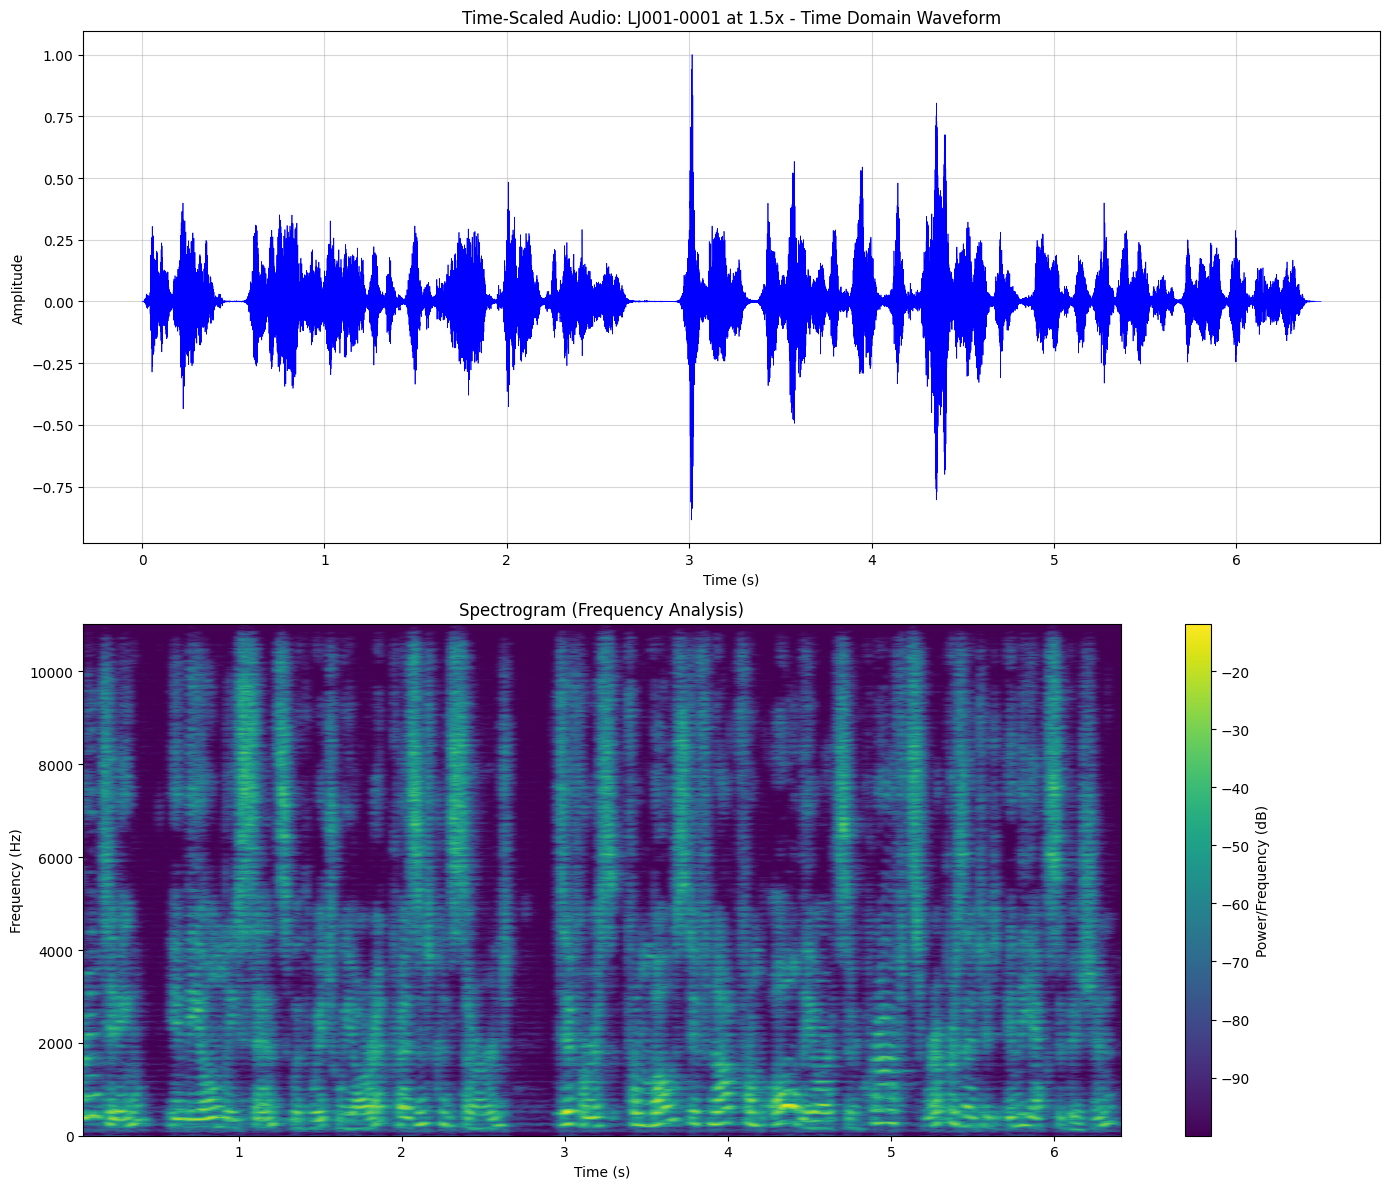

In [77]:
# Begin main execution
def main() -> None:
    try:
        filename, sample_rate, audio_data, playback_speed, rate_factor = read_input()
        print(f"Input file: {filename}\nSample Rate: {sample_rate}\nAudio Length: {len(audio_data)/sample_rate:.2f} seconds")

        y, N, Ra = phase_vocoder(audio_data, rate_factor, sample_rate)

        output_filename = f"outputs/{filename}_{playback_speed}x.wav"
        wavfile.write(output_filename, sample_rate, y)
        print(f"Output written to: {output_filename}\nAudio Length: {len(y)/sample_rate:.2f} seconds")

        print("F0 RMSE: {:.3f}".format(calculate_yin_f0_accuracy(audio_data, y, sample_rate, Ra)))

        plot_audio_analysis('inputs/' + filename + '.wav', N, Ra, sample_rate, title=f"Original Audio: {filename}")
        plot_audio_analysis(output_filename, N, Ra, sample_rate, title=f"Time-Scaled Audio: {filename} at {playback_speed}x")
    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    main()